In [37]:
## =========================================================
## 脚本：Ferroptosis × Neurogenesis (qNSC / nIPC / NB / GC)
## 依赖对象：Seurat_combined_with_Celltype_Article.rds
## =========================================================

library(Seurat)
library(dplyr)
library(ggplot2)

## ---------------- 0. 路径与读入 ----------------
data_dir <- "~/mmFerroptosis/data/GSE233363"

combined <- readRDS(
  file.path(data_dir, "Seurat_combined_with_Celltype_Article.rds")
)

DefaultAssay(combined) <- "RNA"

# 看一下 Age / Celltype_Article
combined$Age <- combined$timepoint

table(combined$Age)
table(combined$Celltype_Article)

## 如果你有 Old1 / Old2 这样的细分年龄，可以合并成一个统一 Old 组
## 保留原始 Age 的同时再建一个 Age_collapsed
combined$Age_collapsed <- combined$Age
combined$Age_collapsed[combined$Age_collapsed %in% c("Old1", "Old2", "Old")] <- "Old"
combined$Age_collapsed[combined$Age_collapsed %in% c("MiddleAge", "Middle")] <- "Middle"

combined$Age_collapsed <- factor(
  combined$Age_collapsed,
  levels = c("Young", "Middle", "Old")  # 按需要调整
)

table(combined$Age_collapsed)


Middle   Old1   Old2  Young 
  9948  12731   9301   5571 


    Astrocyte Cajal-Retzius   Endothelial            GC     Microglia 
         7337           619          2727          6300         18823 
   Neuroblast           OPC      Pericyte           SMC          nIPC 
          280           231           713            74           156 
         qNSC 
          291 


 Young Middle    Old 
  5571   9948  22032 

            
             Young Middle  Old
  Astrocyte   1338   2103 3896
  GC          1543    897 3860
  Neuroblast   160     67   53
  nIPC          74     28   54
  qNSC         139     85   67

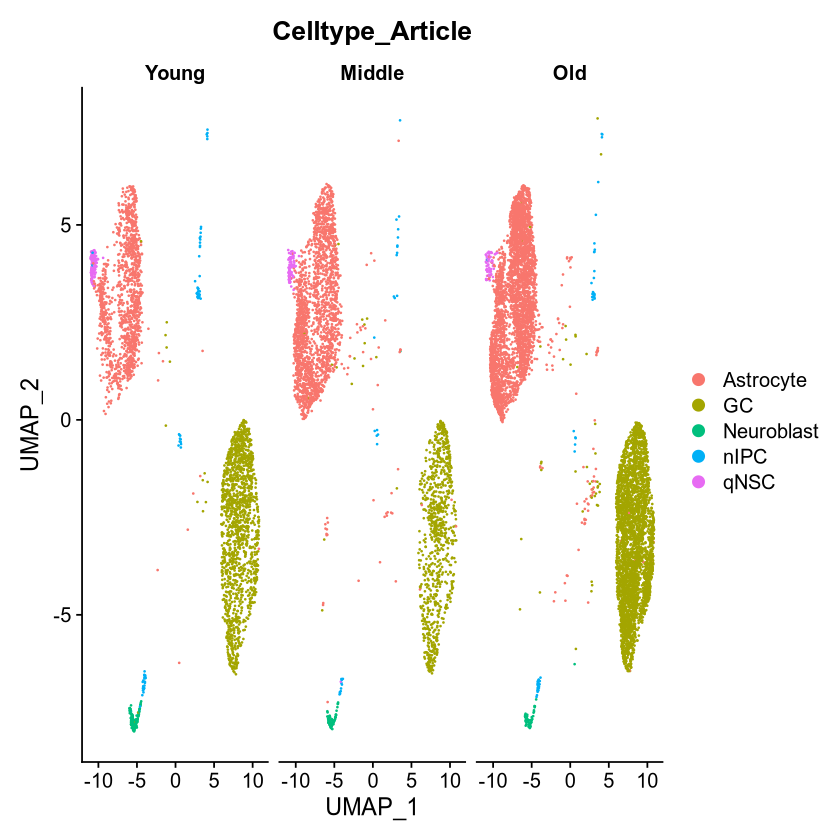

In [42]:
## ---------------- 1. 只保留神经发生相关细胞 ----------------
neuro_ct <- c("qNSC", "nIPC", "Neuroblast", "GC", "Astrocyte")

neuro <- subset(
  combined,
  subset = Celltype_Article %in% neuro_ct
)

neuro$Celltype_Article <- factor(neuro$Celltype_Article)

table(neuro$Celltype_Article, neuro$Age_collapsed)

# 简单 UMAP 看一下这五类细胞（按合并后的 Age_collapsed 分）
DimPlot(
  neuro,
  reduction = "umap",
  group.by  = "Celltype_Article",
  split.by  = "Age_collapsed"
)

In [45]:
## ---------------- 2. 定义 ferroptosis 基因列表 ----------------
## 这里用你整理的 ferroptosis 相关基因；可以按需要继续补充

ferro_genes_raw <- c(
  "Vdac2", "Vdac3",
  "Gpx4", "Hspb1",
  "Nfe2l2",
  "Nox1", "Nox4",
  "Trp53",
  "Slc7a11",
  "Terf1",
  "Ras",
  "Cars", "Eprs", "Hars",
  "Acsf2", "Emc2", "Rpl8", "Ireb2",
  "Cs", "Atp5g3",
  "Gclc",
  "Acsl4", "Lpcat3",
  "Gls2", "Got1",
  "Aco1",
  "Slc38a1",
  "G6pdx",
  "Ttc35",
  "Rb",
  "Chac1",
  "Ptges2",
  "Alox12",
  "Fth1", "Tfrc"
)

ferro_genes_raw <- unique(ferro_genes_raw)

# 只保留在对象里真实存在的基因
genes_in_obj     <- rownames(neuro)
ferro_genes_use  <- intersect(ferro_genes_raw, genes_in_obj)

cat("原始 ferroptosis 基因数:", length(ferro_genes_raw), "\n")
cat("在对象中实际存在的 ferroptosis 基因数:", length(ferro_genes_use), "\n")
cat("未匹配上的基因:\n")
print(setdiff(ferro_genes_raw, ferro_genes_use))

原始 ferroptosis 基因数: 35 
在对象中实际存在的 ferroptosis 基因数: 32 
未匹配上的基因:
[1] "Ras"   "Ttc35" "Rb"   


[1] "FerroScore1"

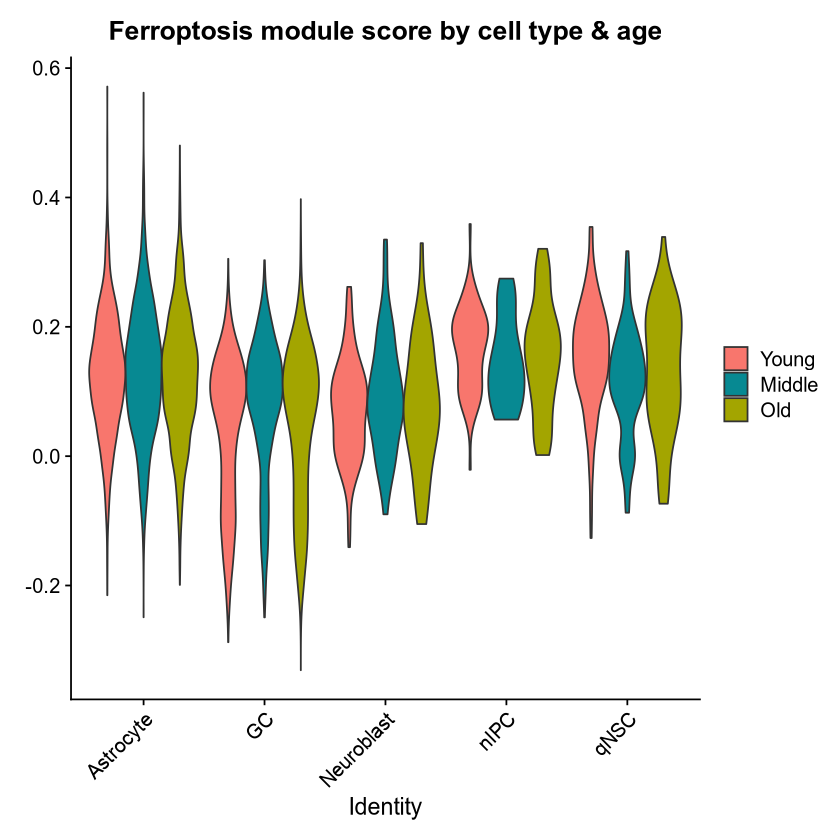

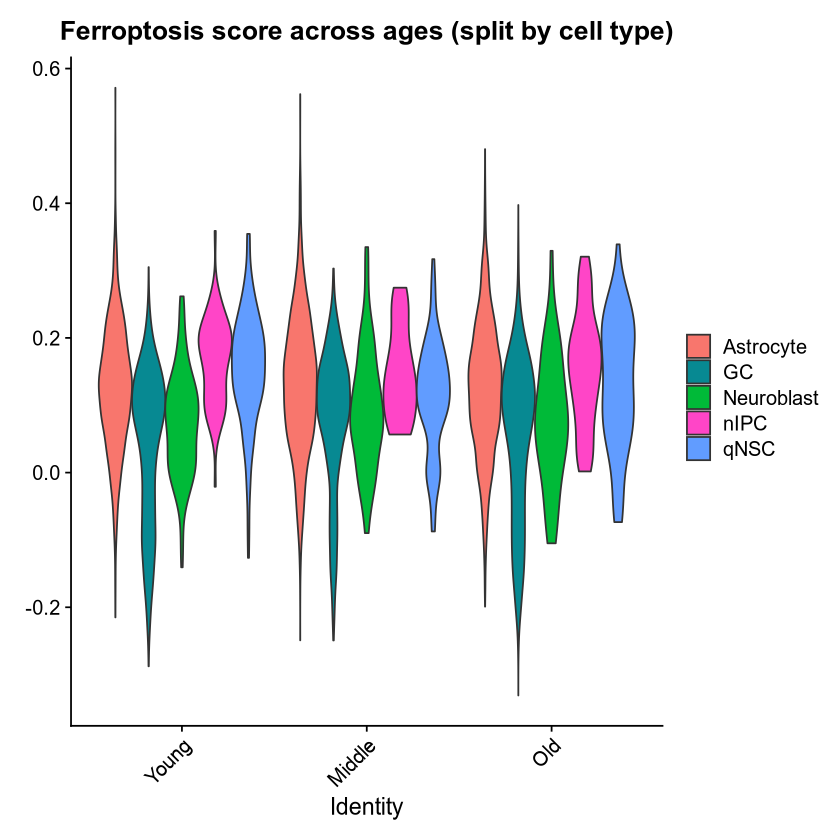

In [46]:
## ---------------- 3. 计算 Ferroptosis module score ----------------
neuro <- AddModuleScore(
  object   = neuro,
  features = list(ferro_genes_use),
  name     = "FerroScore"
)
# 新列名：FerroScore1
colnames(neuro@meta.data)[grepl("^FerroScore", colnames(neuro@meta.data))]

# violin 图：按 celltype & Age_collapsed 看 ferroptosis score
VlnPlot(
  neuro,
  features = "FerroScore1",
  group.by = "Celltype_Article",
  split.by = "Age_collapsed",
  pt.size  = 0
) + ggtitle("Ferroptosis module score by cell type & age")

# 按 Age_collapsed 为主，分 cell type
VlnPlot(
  neuro,
  features = "FerroScore1",
  group.by = "Age_collapsed",
  split.by = "Celltype_Article",
  pt.size  = 0
) + ggtitle("Ferroptosis score across ages (split by cell type)")

# A tibble: 15 × 5
   Celltype_Article Age_collapsed mean_score sd_score n_cells
   <fct>            <fct>              <dbl>    <dbl>   <int>
 1 Astrocyte        Young             0.125    0.0931    1338
 2 Astrocyte        Middle            0.130    0.101     2103
 3 Astrocyte        Old               0.123    0.0993    3896
 4 GC               Young             0.0385   0.113     1543
 5 GC               Middle            0.0758   0.104      897
 6 GC               Old               0.0494   0.118     3860
 7 Neuroblast       Young             0.0724   0.0767     160
 8 Neuroblast       Middle            0.0939   0.0886      67
 9 Neuroblast       Old               0.0791   0.0959      53
10 nIPC             Young             0.166    0.0635      74
11 nIPC             Middle            0.148    0.0684      28
12 nIPC             Old               0.154    0.0846      54
13 qNSC             Young             0.154    0.0849     139
14 qNSC             Middle            0.111    0.08

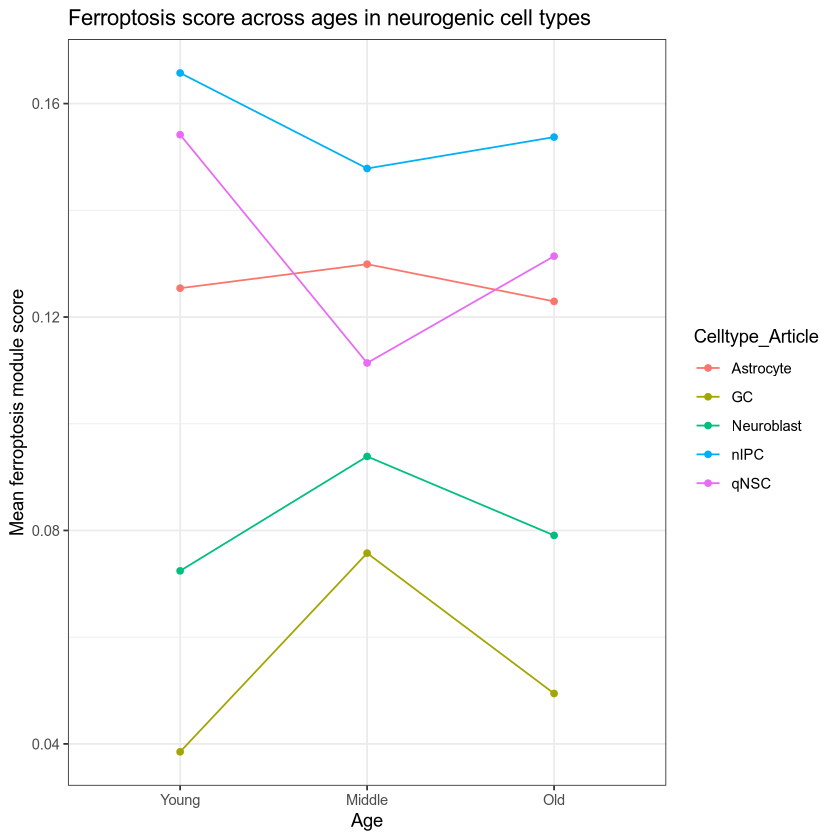

In [20]:
## ---------------- 4. 统计不同年龄 × 细胞类型的均值 ----------------
ferro_df <- FetchData(
  neuro,
  vars = c("FerroScore1", "Age_collapsed", "Celltype_Article")
)

ferro_summary <- ferro_df %>%
  group_by(Celltype_Article, Age_collapsed) %>%
  summarise(
    mean_score = mean(FerroScore1, na.rm = TRUE),
    sd_score   = sd(FerroScore1, na.rm = TRUE),
    n_cells    = n(),
    .groups    = "drop"
  )

print(ferro_summary)

ggplot(ferro_summary,
       aes(x = Age_collapsed, y = mean_score,
           group = Celltype_Article, color = Celltype_Article)) +
  geom_line() +
  geom_point() +
  theme_bw() +
  ylab("Mean ferroptosis module score") +
  xlab("Age") +
  ggtitle("Ferroptosis score across ages in neurogenic cell types")

In [21]:
## ---------------- 5. 针对 ferroptosis 基因做差异表达 ----------------
## 在每个 celltype 内比较 Young vs Old（用 Age_collapsed）

run_ferro_DE_in_celltype <- function(seu, celltype,
                                     age1 = "Young", age2 = "Old",
                                     ferro_genes = ferro_genes_use,
                                     test.use = "wilcox") {
  message("Running DE for ", celltype, ": ", age1, " vs ", age2)
  
  sub <- subset(
    seu,
    subset = Celltype_Article == celltype &
      Age_collapsed %in% c(age1, age2)
  )
  
  if (ncol(sub) < 50) {
    warning("Too few cells for ", celltype, " / ", age1, " vs ", age2)
    return(NULL)
  }
  
  Idents(sub) <- sub$Age_collapsed
  
  de <- FindMarkers(
    sub,
    ident.1         = age1,
    ident.2         = age2,
    features        = ferro_genes,
    logfc.threshold = 0,
    min.pct         = 0.05,
    test.use        = test.use
  )
  
  de$gene     <- rownames(de)
  de$celltype <- celltype
  de$age1     <- age1
  de$age2     <- age2
  
  de <- de %>%
    arrange(p_val_adj, desc(avg_log2FC))
  
  return(de)
}

neuro_ct <- c("qNSC", "nIPC", "Neuroblast", "GC")

res_list <- list()
for (ct in neuro_ct) {
  res_list[[ct]] <- run_ferro_DE_in_celltype(
    seu         = neuro,
    celltype    = ct,
    age1        = "Young",
    age2        = "Old",
    ferro_genes = ferro_genes_use,
    test.use    = "wilcox"   # 或 "MAST"（需安装 MAST）
  )
}

ferro_de_all <- bind_rows(res_list)

ferro_de_sig <- ferro_de_all %>%
  filter(p_val_adj < 0.05 & abs(avg_log2FC) > 0.25)

write.csv(
  ferro_de_all,
  file = file.path(data_dir, "ferro_DE_all_neurogenic_cells.csv"),
  row.names = FALSE
)

write.csv(
  ferro_de_sig,
  file = file.path(data_dir, "ferro_DE_sig_neurogenic_cells.csv"),
  row.names = FALSE
)

Running DE for qNSC: Young vs Old

Running DE for nIPC: Young vs Old

Running DE for Neuroblast: Young vs Old

Running DE for GC: Young vs Old



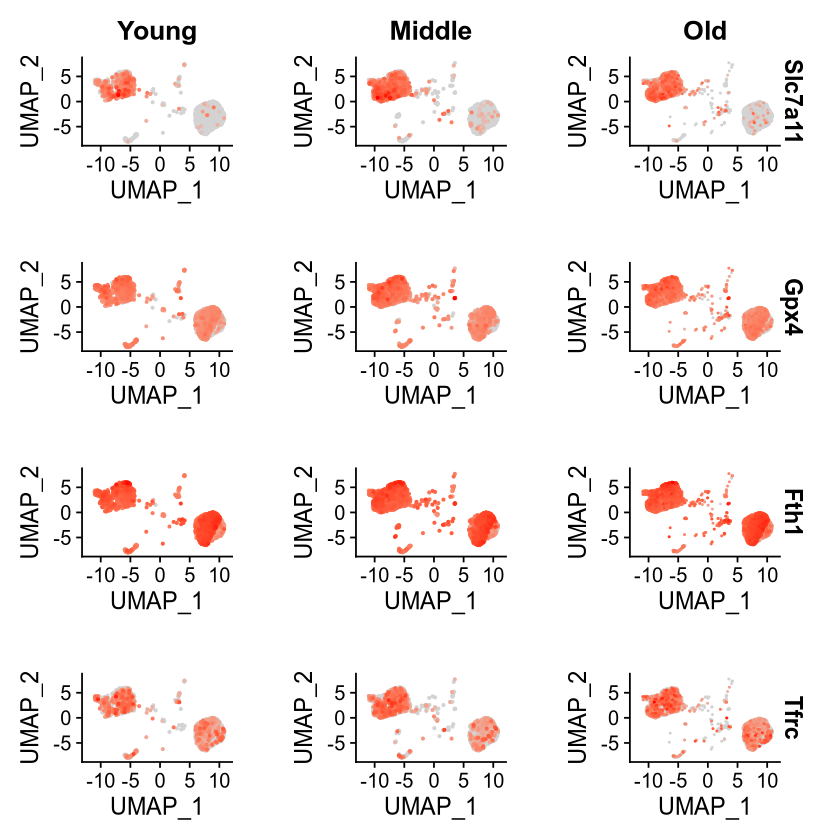

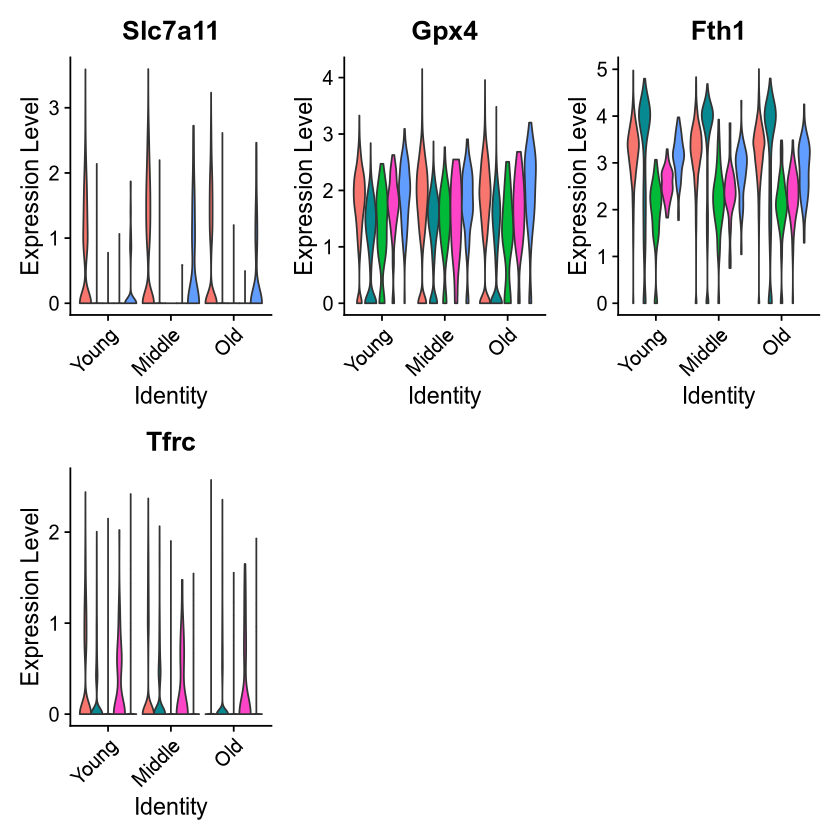

In [22]:
## ---------------- 6. 针对单个 ferroptosis 基因画图（示例） ----------------
genes_example <- c("Slc7a11", "Gpx4", "Fth1", "Tfrc")
genes_example <- intersect(genes_example, rownames(neuro))

FeaturePlot(
  neuro,
  features = genes_example,
  split.by = "Age_collapsed",
  cols     = c("lightgrey", "red"),
  order    = TRUE
)

VlnPlot(
  neuro,
  features = genes_example,
  group.by = "Age_collapsed",
  split.by = "Celltype_Article",
  pt.size  = 0
)

In [23]:
## ---------------- 7. 保存 neuro 对象（可选） ----------------
saveRDS(
  neuro,
  file = file.path(data_dir, "Seurat_neurogenic_cells_with_FerroScore.rds")
)

## 衰老过程中神经发生谱系的“产量”变化

In [24]:
table(neuro$Celltype_Article, neuro$Age_collapsed)

            
             Young Middle  Old
  Astrocyte   1338   2103 3896
  GC          1543    897 3860
  Neuroblast   160     67   53
  nIPC          74     28   54
  qNSC         139     85   67

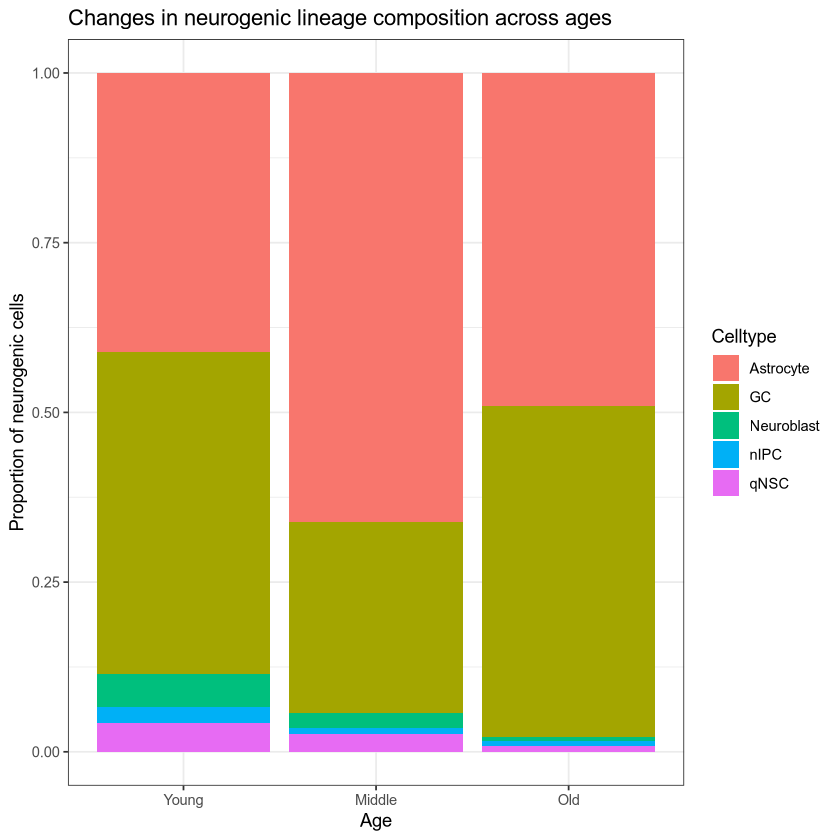

In [25]:
prop_df <- as.data.frame(table(neuro$Celltype_Article, neuro$Age_collapsed))
colnames(prop_df) <- c("Celltype", "Age", "Freq")

prop_df <- prop_df %>%
  group_by(Age) %>%
  mutate(Prop = Freq / sum(Freq))

ggplot(prop_df, aes(x = Age, y = Prop, fill = Celltype)) +
  geom_bar(stat = "identity") +
  ylab("Proportion of neurogenic cells") +
  ggtitle("Changes in neurogenic lineage composition across ages") +
  theme_bw()

## H2：ferroptosis 活性在神经发生谱系中如何随年龄变化

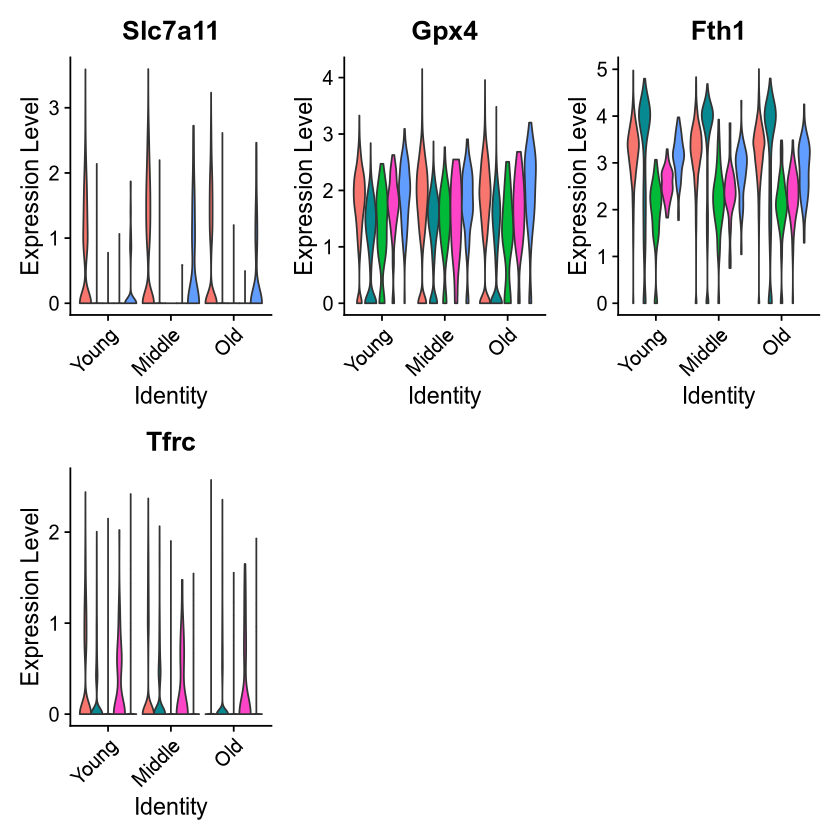

In [26]:
genes_example <- c("Slc7a11", "Gpx4", "Fth1", "Tfrc", "AcsL4")
genes_example <- intersect(genes_example, rownames(neuro))

VlnPlot(
  neuro,
  features = genes_example,
  group.by = "Age_collapsed",
  split.by = "Celltype_Article",
  pt.size  = 0
)


## H3：ferroptosis 高的 NSC / nIPC 是否“更不容易神经发生”？


High  Low 
  34   33 

Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of Mki67.”


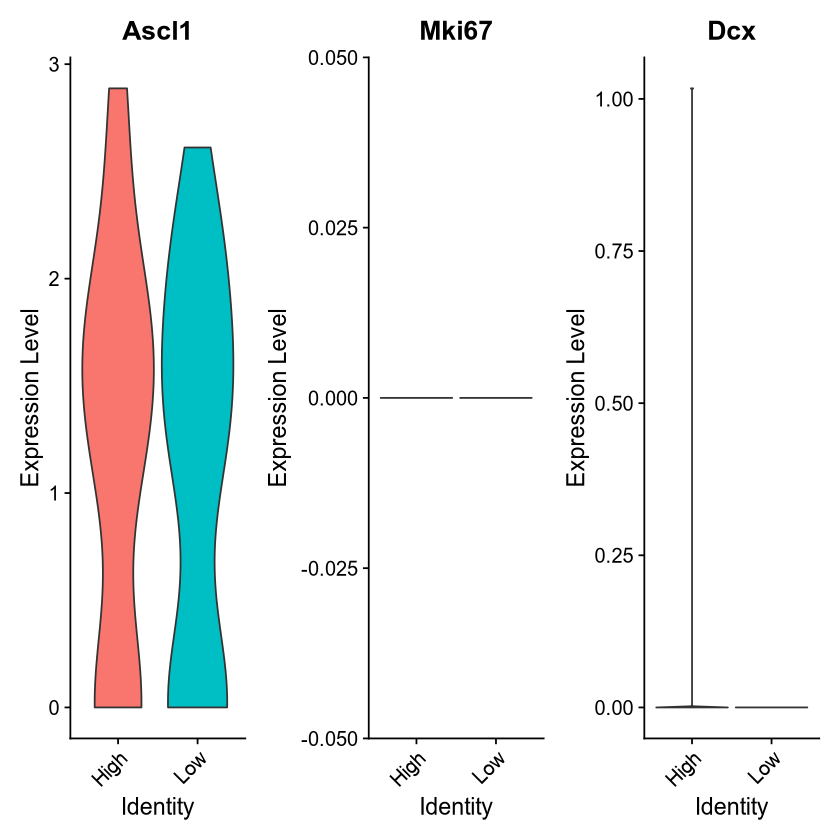

In [27]:
# 只看 Old 组的 qNSC
qNSC_old <- subset(
  neuro,
  subset = Celltype_Article == "qNSC" & Age_collapsed == "Old"
)

# 按 FerroScore1 的中位数分高低
cutoff <- median(qNSC_old$FerroScore1, na.rm = TRUE)
qNSC_old$Ferro_group <- ifelse(qNSC_old$FerroScore1 >= cutoff, "High", "Low")

table(qNSC_old$Ferro_group)

# 看看 Ascl1 / Mki67 / Dcx 在 High vs Low 的差异
VlnPlot(
  qNSC_old,
  features = c("Ascl1", "Mki67", "Dcx"),
  group.by = "Ferro_group",
  pt.size  = 0
)


In [28]:
Idents(qNSC_old) <- qNSC_old$Ferro_group

de_qNSC_old_ferro <- FindMarkers(
  qNSC_old,
  ident.1         = "High",
  ident.2         = "Low",
  logfc.threshold = 0.25,
  min.pct         = 0.1
)

head(de_qNSC_old_ferro[order(de_qNSC_old_ferro$p_val_adj), ])


Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Eprs,0.0000172749,1.1312456,0.676,0.212,0.3617537
Akap11,0.0001510551,0.8678541,0.412,0.030,1.0000000
Mtln,0.0002235790,0.9708766,0.588,0.152,1.0000000
Mapre1,0.0003327707,0.8631546,0.735,0.273,1.0000000
Hspd1,0.0005437624,0.8608881,0.794,0.455,1.0000000
Ptprf,0.0006057740,-0.9168376,0.000,0.303,1.0000000


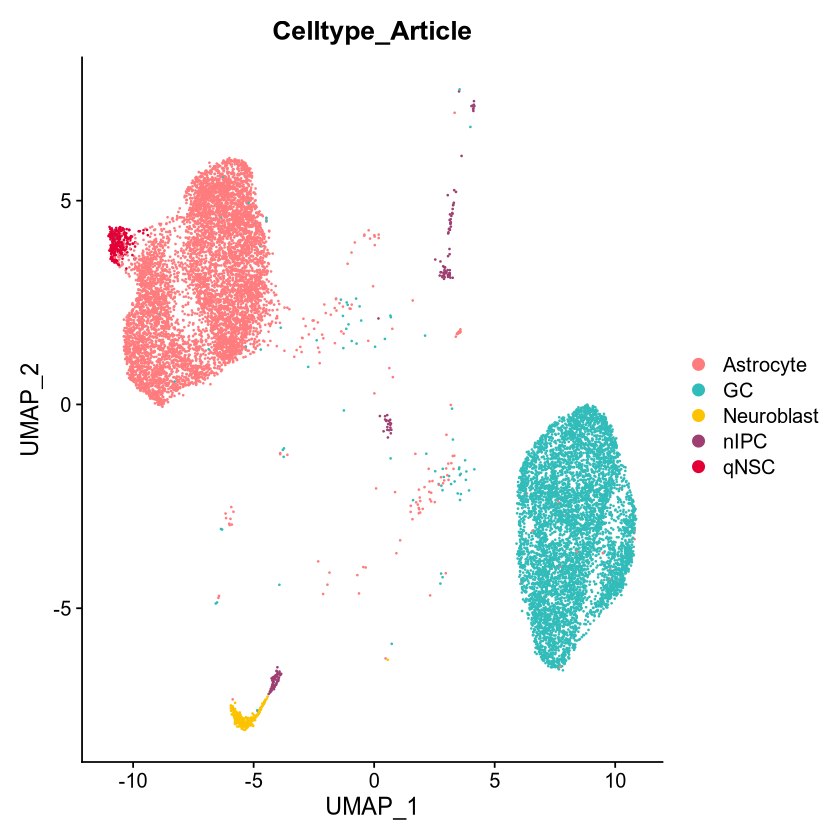

In [36]:
celltype_colors <- c(
  "qNSC"       = "#E20035",
  "nIPC"       = "#9E3F71",
  "Neuroblast" = "#FEC300",
  "GC"         = "#31BCBA",
  "Astrocyte"  = "#FF7C7E"
)



DimPlot(
  neuro,
  reduction = "umap",
  group.by  = "Celltype_Article",
  cols      = celltype_colors_1
)
